In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
# import warnings
# warnings.filterwarnings("ignore", category=FutureWarning)


In [91]:
# df = pd.read_spss(r"C:\Users\No\Downloads\D00224_2\data.sav")
# df.to_csv('Dataset.csv', encoding='utf-8-sig', index=False)
df = pd.read_csv(r"C:\Users\No\Documents\GitHub\psychic-spoon\0 2025資料科學漫步\Dataset.csv")
df = df[df['rq21a'] == '答對'].reset_index(drop=True) # 篩選有效樣本中的注意力題答對的樣本
df.shape

(685, 211)

---
---
## 基本資料

In [92]:
individual = df.iloc[:,4:10]
individual['q3'] = individual['q3'].str.replace(r'^\(\d+\)', '', regex=True)
individual['q4'] = individual['q4'].str.replace(r'^\(\d+\)', '', regex=True)

# rename_ = {'q1':'性別', 'q2':'出生年','q3':'出生縣市', 'q4':'學歷'}
# individual = individual.rename(columns=rename_).drop(columns=['q3_other', 'q4_88_text'])
individual = individual.drop(columns=['q3_other', 'q4_88_text'])

individual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   q1      685 non-null    object 
 1   q2      685 non-null    float64
 2   q3      685 non-null    object 
 3   q4      685 non-null    object 
dtypes: float64(1), object(3)
memory usage: 21.5+ KB


In [93]:
individual['birthyear_ad'] = individual['q2']+1911
individual['age'] = 2021-individual['birthyear_ad']
bins = [0, 29, 44, 59, 120]
labels = ['青年', '壯年', '中年', '老年']
individual['age_g'] = pd.cut(individual['age'], bins=bins, labels=labels, right=True)
def edu_group(x):
    if x in ["國(初)中"]:
        return "國中以下"
    elif x in ["高職(高商、高工)", "高中職業科", "高中普通科", "軍警專修班", "軍警專科班", "二專", "三專", "五專", "空中行專"]:
        return "高中職"
    elif x in ["大學", "技術學院、科大", "空中大學", "軍警官校或大學"]:
        return "大學"
    elif x in ["碩士", "博士"]:
        return "研究所以上"
    else:
        return None

individual["edu_g"] = individual["q4"].apply(edu_group)
individual

,q1,q2,q3,q4,birthyear_ad,age,age_g,edu_g
0,女,54.0,台北市,碩士,1965.0,56.0,中年,研究所以上
1,男,58.0,台北市,博士,1969.0,52.0,中年,研究所以上
2,女,73.0,新北市,碩士,1984.0,37.0,壯年,研究所以上
3,男,86.0,台北市,碩士,1997.0,24.0,青年,研究所以上
4,女,85.0,台北市,大學,1996.0,25.0,青年,大學
...,...,...,...,...,...,...,...,...
680,男,87.0,高雄市,大學,1998.0,23.0,青年,大學
681,女,81.0,屏東縣,大學,1992.0,29.0,青年,大學
682,女,76.0,屏東縣,碩士,1987.0,34.0,壯年,研究所以上
683,女,83.0,屏東縣,大學,1994.0,27.0,青年,大學


## 網路使用行為

In [94]:
# internet_usage = df.iloc[:,11:59]

# internet_usage['q6'] = np.round((internet_usage['q6_h'] + internet_usage['q6_m']/60), 4)
# internet_usage['q7'] = np.round((internet_usage['q7_h'] + internet_usage['q7_m']/60), 4)
# cols =  internet_usage.columns.tolist()
# i ,j = cols.index('q6_h'), cols.index('q6')
# cols[i], cols[j] = cols[j], cols[i]
# i ,j = cols.index('q6_m'), cols.index('q7')
# cols[i], cols[j] = cols[j], cols[i]
# internet_usage = internet_usage[cols].drop(columns=['q6_h', 'q6_m', 'q7_h', 'q7_m'])

# internet_usage_col_replace = {
#                         'q8_1': '(01)維繫友誼與他人保持聯絡(傳LINE、滑臉書等)',
#                         'q8_2': '(02)娛樂消遣(玩遊戲、看卡通動漫、看電影、戲劇、看直播、聽音樂、交友軟體、追星、命理占卜、打發時間、無聊)',
#                         'q8_3': '(03)獲得時事/新聞/政府資訊(搜尋關鍵字、看新聞、看政府資訊、天氣資訊)',
#                         'q8_4': '(04)獲得生活休閒資訊(美食、觀光旅遊、醫療衛生保健、家庭生活、親子婚姻關係、交通資訊)',
#                         'q8_5': '(05)理財消費購物(看理財資訊、網路購物、理財管理、繳費、財經股市)',
#                         'q8_6': '(06)學習或工作(有支薪)(語言學習、線上課程、使用文書處理軟體、學習各種軟體)',    
                        
#                         'q9_1': '(01)LINE',
#                         'q9_2': '(02)Facebook Messenger(臉書聊天室)',
#                         'q9_3': '(03)微信Wechat',
#                         'q9_4': '(04)WhatsApp',
#                         'q9_5': '(05)Hangouts',
#                         'q9_6': '(06)Skype',
#                         'q9_7': '(07)Facetime',
#                         'q9_8': '(08)Telegram',
#                         'q9_88': '(88)其他',

#                         'q10_1': '(01)臉書(Facebook)',
#                         'q10_2': '(02)Instagram',
#                         'q10_3': '(03)推特(Twitter)',
#                         'q10_4': '(04)LinkedIn',
#                         'q10_5': '(05)微博',
#                         'q10_6': '(06)噗浪(Plurk)',
#                         'q10_7': '(07)抖音(TikTok)',
#                         'q10_8': '(08)PTT',
#                         'q10_9': '(09)Dcard',
#                         'q10_10': '(10)Pinterest',
#                         'q10_88': '(88)其他',

#                         'q11_1': '(01)YouTube',
#                         'q11_2': '(02)愛奇藝',
#                         'q11_3': '(03)Netflix 網飛',
#                         'q11_4': '(04)KKTV',
#                         'q11_5': '(05)LINE TV',
#                         'q11_6': '(06)Li TV',
#                         'q11_7': '(07)Twitch',
#                         'q11_8': '(08)friDay影音',
#                         'q11_88': '(88)其他'
#                         }

# def replace_(df, col_map):
#     for col, text in col_map.items():
#         x = df[col].replace(text, 1)
#         x = x.infer_objects(copy=False)
#         x = x.fillna(0)
#         df[col] = x.astype(int)
# replace_(internet_usage, internet_usage_col_replace)

# rename_ = {'q5_1':'每週平均上網天數',
#            'q6':'一天因工作或課業上網小時','q7':'一天因其他所需上網小時',
#            'q8_1':'因維繫友誼與他人保持聯絡上網', 'q8_2':'因娛樂消遣上網', 'q8_3':'因獲得時事/新聞/政府資訊上網', 'q8_4':'因獲得生活休閒資訊上網', 'q8_5':'因理財消費購物上網', 'q8_6':'因學習或工作上網',
#            'q9_1':'最近一個月使用line', 'q9_2':'最近一個月使用Messenger(臉書聊天室)', 'q9_3':'最近一個月使用微信Wechat', 'q9_4':'最近一個月使用WhatsApp', 'q9_5':'最近一個月使用Hangouts', 'q9_6':'最近一個月使用Skype', 'q9_7':'最近一個月使用Facetime', 'q9_8':'最近一個月使用Telegram', 'q9_88':'最近一個月使用其他即時通訊軟體',
#            'q10_1':'最近一個月使用臉書(Facebook)', 'q10_2':'最近一個月使用Instagram', 'q10_3':'最近一個月使用推特(Twitter)', 'q10_4':'最近一個月使用LinkedIn', 'q10_5':'最近一個月使用微博', 'q10_6':'最近一個月使用噗浪(Plurk)', 'q10_7':'最近一個月使用抖音(TikTok)', 'q10_8':'最近一個月使用PTT', 'q10_9':'最近一個月使用Dcard', 'q10_10':'最近一個月使用Pinterest', 'q10_88':'最近一個月使用其他社群媒體',
#            'q11_1':'最近一個月使用YouTube', 'q11_2':'最近一個月使用)愛奇藝', 'q11_3':'最近一個月使用Netflix 網飛', 'q11_4':'最近一個月使用KKTV', 'q11_5':'最近一個月使用LINE TV', 'q11_6':'最近一個月使用Li TV', 'q11_7':'最近一個月使用Twitch', 'q11_8':'最近一個月使用friDay影音', 'q11_88':'最近一個月使用其他影音平台'}
# internet_usage = internet_usage.rename(columns=rename_).drop(columns=['q8_88', 'q8_88_text', 'q8_90', 'q9_88_text', 'q9_90', 'q10_88_text', 'q10_90', 'q11_88_text', 'q11_90'])
# internet_usage.info()

---
---

## 網路攻擊行為

- 'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話'
- 'q22_02_1':'多常在網路上看別人兇激怒他的人'
- 'q22_03_1':'多常在網路上看到別人罵討厭他的人'
- 'q22_04_1':'多常在網路上看到別人開不雅玩笑'
- 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
- 'q23_01_1':'多常在網路上留言髒話/不好聽的話'
- 'q23_02_1':'多常在網路上兇激怒你的人'
- 'q23_03_1':'多常在網路上罵討厭你的人'
- 'q23_04_1':'多常在網路上開不雅玩笑'
- 'q23_05_1':'多常在網路上用諷刺方式回覆他人'

In [95]:
internet_attack = df.iloc[:, 156:166]

times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
times_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1',
              'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
for col in times_cols:
    internet_attack[col] = pd.to_numeric(internet_attack[col].replace(times_score))
    
# rename_ = {'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話', 'q22_02_1':'多常在網路上看別人兇激怒他的人', 'q22_03_1':'多常在網路上看到別人罵討厭他的人', 'q22_04_1':'多常在網路上看到別人開不雅玩笑', 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
#            'q23_01_1':'多常在網路上留言髒話/不好聽的話', 'q23_02_1':'多常在網路上兇激怒你的人', 'q23_03_1':'多常在網路上罵討厭你的人', 'q23_04_1':'多常在網路上開不雅玩笑', 'q23_05_1':'多常在網路上用諷刺方式回覆他人'}
# internet_attack = internet_attack.rename(columns=rename_)
internet_attack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   q22_01_1  685 non-null    int64
 1   q22_02_1  685 non-null    int64
 2   q22_03_1  685 non-null    int64
 3   q22_04_1  685 non-null    int64
 4   q22_05_1  685 non-null    int64
 5   q23_01_1  685 non-null    int64
 6   q23_02_1  685 non-null    int64
 7   q23_03_1  685 non-null    int64
 8   q23_04_1  685 non-null    int64
 9   q23_05_1  685 non-null    int64
dtypes: int64(10)
memory usage: 53.6 KB


C:\Users\No\AppData\Local\Temp\ipykernel_8976\1725912608.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  internet_attack[col] = pd.to_numeric(internet_attack[col].replace(times_score))


In [96]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

internet_attack_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1', 'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
internet_attack['total'] = internet_attack[internet_attack_cols].sum(axis=1)
n_ext = int(len(internet_attack)*.27)
high = internet_attack.nlargest(n_ext, 'total')
low = internet_attack.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(internet_attack[internet_attack_cols])

for i in internet_attack_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = internet_attack[i].corr(internet_attack['total'] - internet_attack[i])
    alpha_del = cronbach_alpha(internet_attack[[col for col in internet_attack_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = internet_attack.shape[0], len(internet_attack_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')


        col      t    p      ri  alpha_del   flag
0  q22_01_1  24.92  0.0  0.6439     0.8354  False
1  q22_02_1  25.02  0.0  0.6851     0.8313  False
2  q22_03_1  26.94  0.0  0.6756     0.8322  False
3  q22_04_1  25.85  0.0  0.6318     0.8366  False
4  q22_05_1  24.84  0.0  0.6288     0.8368  False
5  q23_01_1  13.21  0.0  0.4603     0.8509  False
6  q23_02_1  13.66  0.0  0.4725     0.8500  False
7  q23_03_1  13.91  0.0  0.4904     0.8487  False
8  q23_04_1  10.96  0.0  0.4084     0.8544  False
9  q23_05_1  15.50  0.0  0.4912     0.8489  False
-------------------------------------------------
信度分析: Cronbach α = 0.856443  (95% CI: 0.8399 – 0.8720)


In [97]:
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
kmo_all, kmo_model = calculate_kmo(internet_attack[internet_attack_cols])
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(internet_attack[internet_attack_cols])
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

KMO = 0.8761
'Bartlett's chi2 = 3296.55, p = 0.0000


---
---

## 網路攻擊接受度

In [98]:
internet_attack_accepted = pd.concat([df.iloc[:, 147:149], df.iloc[:, 171:175]], axis=1)

acceptance_score = {'可以接受':5, '稍微可以接受':4, '普通':3, '有點不可以接受':2,'不可以接受':1}
acceptance_cols = ['q20_01_1', 'q20_02_1',
                   'q25_01_1', 'q25_02_1', 'q25_03_1', 'q25_04_1']

for col in acceptance_cols:
    internet_attack_accepted[col] = pd.to_numeric(internet_attack_accepted[col].replace(acceptance_score))

rename_ = {'q20_01_1':'在網路上謾罵討厭的人使其知道他不屬於您的團體', 'q20_02_1':'為了獲得想要的而在網路上謾罵他人',
           'q25_01_1':'在網路上對與您意見不同的人講挑釁的話', 'q25_02_1':'在網路上對討論政治話題的人講挑釁的話', 'q25_03_1':'在網路上對攻擊您看法的人謾罵', 'q25_04_1':'在網路上對與您意見不同的人謾罵'}
internet_attack_accepted = internet_attack_accepted.rename(columns=rename_)
internet_attack_accepted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   在網路上謾罵討厭的人使其知道他不屬於您的團體  685 non-null    int64
 1   為了獲得想要的而在網路上謾罵他人        685 non-null    int64
 2   在網路上對與您意見不同的人講挑釁的話      685 non-null    int64
 3   在網路上對討論政治話題的人講挑釁的話      685 non-null    int64
 4   在網路上對攻擊您看法的人謾罵          685 non-null    int64
 5   在網路上對與您意見不同的人謾罵         685 non-null    int64
dtypes: int64(6)
memory usage: 32.2 KB


C:\Users\No\AppData\Local\Temp\ipykernel_8976\2276666400.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  internet_attack_accepted[col] = pd.to_numeric(internet_attack_accepted[col].replace(acceptance_score))


---
---

## 心理幸福感/生活品質

In [99]:
happiness = pd.concat([df.iloc[:, 140:141], df.iloc[:, -12:-9]], axis=1)

satisfy_score = {'非常滿意':5, '滿意':4, '普通':3, '不滿意':2,'非常不滿意':1}
satisfy_cols = ['q15_03_1', 'q38_01_1', 'q38_02_1']
for col in satisfy_cols:
    happiness[col] = pd.to_numeric(happiness[col].replace(satisfy_score))

happy_score = {'非常快樂':5, '快樂':4, '普通':3, '不快樂':2,'非常不快樂':1}
happy_cols = ['q39_1']
for col in happy_cols:
    happiness[col] = pd.to_numeric(happiness[col].replace(happy_score))

satisfysatisfy_cols = ['q15_03_1', 'q38_01_1', 'q38_02_1', 'q39_1']
for col in satisfysatisfy_cols:
    happiness[col] = happiness[col].fillna(happiness[col].max()).astype(int)
    
# rename_ = {'q15_03_1':'對於政府目前處理疫情的滿意程度', 'q38_01_1':'對於生活的滿意程度',
#            'q38_02_1':'對於目前台灣社會的滿意程度', 'q39_1':'對於目前日子的快樂程度'}
# happiness = happiness.rename(columns=rename_)
happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   q15_03_1  685 non-null    int32
 1   q38_01_1  685 non-null    int32
 2   q38_02_1  685 non-null    int32
 3   q39_1     685 non-null    int32
dtypes: int32(4)
memory usage: 10.8 KB


C:\Users\No\AppData\Local\Temp\ipykernel_8976\45203834.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  happiness[col] = pd.to_numeric(happiness[col].replace(satisfy_score))
C:\Users\No\AppData\Local\Temp\ipykernel_8976\45203834.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  happiness[col] = pd.to_numeric(happiness[col].replace(happy_score))


In [100]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

happiness['total'] = happiness[satisfysatisfy_cols].sum(axis=1)
n_ext = int(len(happiness)*.27)
high = happiness.nlargest(n_ext, 'total')
low = happiness.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(happiness[satisfysatisfy_cols])

for i in satisfysatisfy_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = happiness[i].corr(happiness['total'] - happiness[i])
    alpha_del = cronbach_alpha(happiness[[col for col in satisfysatisfy_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = happiness.shape[0], len(satisfysatisfy_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
happiness = happiness.drop(columns='q15_03_1')

        col      t    p      ri  alpha_del   flag
0  q15_03_1  23.93  0.0  0.4384     0.7535   True
1  q38_01_1  20.67  0.0  0.5307     0.6820  False
2  q38_02_1  28.17  0.0  0.6387     0.6173  False
3     q39_1  22.81  0.0  0.5596     0.6651  False
-------------------------------------------------
信度分析: Cronbach α = 0.738177  (95% CI: 0.7046 – 0.7688)


In [101]:
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
kmo_all, kmo_model = calculate_kmo(happiness[['q38_01_1', 'q38_02_1', 'q39_1']])
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(happiness[['q38_01_1', 'q38_02_1', 'q39_1']])
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

KMO = 0.6459
'Bartlett's chi2 = 580.98, p = 0.0000


---
---


## 網路抵制

In [102]:
cancel_culture1

0      3
1      3
2      3
3      3
4      4
      ..
680    4
681    2
682    3
683    2
684    2
Name: q33_1, Length: 685, dtype: Int64

In [103]:
cancel_culture1 = pd.concat([df.iloc[:, 178:179], df.iloc[:, 191:198]], axis=1)

def map_fill_mode(s: pd.Series, mapping: dict) -> pd.Series:
    # 先清理→映射→轉數字（未對應或雜訊變 NaN）
    x = s.astype(str).str.strip().replace(mapping)
    x = pd.to_numeric(x, errors='coerce')
    # 以眾數填補（若全是 NaN 就保留 NaN）
    m = x.mode(dropna=True)
    return x.fillna(m.iloc[0]) if not m.empty else x
want_score = {'非常不想':1, '不想':2, '普通':3, '想':4, '非常想':5}
times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
effect_score = {'完全沒有效':1, '沒有效':2, '普通':3, '有效':4, '非常有效':5}
serious_score = {'非常不嚴重':1, '不嚴重':2, '普通':3, '嚴重':4, '非常嚴重':5}
important_score = {'非常不重要':1, '不重要':2, '普通':3, '重要':4, '非常重要':5}
cost_score = {'非常少':1, '有點少':2, '普通':3, '有點多':4, '非常多':5}

col_maps = {
    'q27_1': want_score,
    'q30_1': effect_score,
    'q31_1': times_score,
    'q36_1': times_score,
    'q32_1': serious_score,
    'q33_1': important_score,
    'q34_1': cost_score,
    'q35_1': cost_score,
}

# 套用到所有欄位；用 Int64 以容許少量殘留 NA（若確定無 NA 再轉 int）
for c, m in col_maps.items():
    cancel_culture1[c] = map_fill_mode(cancel_culture1[c], m).astype('Int64')

# rename_ = {'q27_1':'多想透過社群媒體抵制言行不當的名人', 'q30_1':'使名人改善其行為而透過社群媒體抵制的效果', 'q34_1':'社群媒體抵制對您的損失', 'q35_1':'過去與您參與社群媒體抵制的人數'}
# cancel_culture = cancel_culture.rename(columns=rename_).drop(columns=['q28_4_text', 'q29_5_text'])
cancel_culture1_cols = ['q27_1', 'q30_1', 'q31_1', 'q32_1', 'q33_1', 'q34_1', 'q35_1', 'q36_1']
cancel_culture1

C:\Users\No\AppData\Local\Temp\ipykernel_8976\1886264819.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = s.astype(str).str.strip().replace(mapping)


,q27_1,q30_1,q31_1,q32_1,q33_1,q34_1,q35_1,q36_1
0,3,4,3,4,3,1,3,2
1,3,3,3,3,3,1,1,2
2,2,4,3,4,3,1,3,2
3,5,1,3,3,3,1,4,3
4,4,4,3,3,4,1,4,2
...,...,...,...,...,...,...,...,...
680,4,3,2,4,4,2,5,2
681,4,3,2,3,2,2,2,2
682,3,3,3,3,3,3,4,1
683,2,4,1,4,2,1,4,1


In [104]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

cancel_culture1['total'] = cancel_culture1[cancel_culture1_cols].sum(axis=1)
n_ext = int(len(cancel_culture1)*.27)
high = cancel_culture1.nlargest(n_ext, 'total')
low = cancel_culture1.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(cancel_culture1[cancel_culture1_cols])

for i in cancel_culture1_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = cancel_culture1[i].corr(cancel_culture1['total'] - cancel_culture1[i])
    alpha_del = cronbach_alpha(cancel_culture1[[col for col in cancel_culture1_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = cancel_culture1.shape[0], len(cancel_culture1_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
cancel_culture1 = cancel_culture1['q33_1']

     col      t    p      ri  alpha_del   flag
0  q27_1  11.63  0.0  0.0952     0.4890   True
1  q30_1  11.01  0.0  0.2379     0.4127   True
2  q31_1   7.08  0.0  0.2103     0.4268   True
3  q32_1   6.81  0.0  0.1517     0.4470   True
4  q33_1  13.46  0.0  0.3789     0.3570  False
5  q34_1   9.05  0.0  0.0912     0.4785   True
6  q35_1  12.63  0.0  0.2838     0.3894   True
7  q36_1  10.40  0.0  0.2690     0.4106   True
-------------------------------------------------
信度分析: Cronbach α = 0.460632  (95% CI: 0.3974 – 0.5196)


In [105]:
cancel_culture2 = df.iloc[:, 179:191]

cancel_culture_col_replace = {
                        'q28_1': '(01)取消關注他們的粉專或帳號',
                        'q28_2': '(02)拒絕觀看他們的發文或影音',
                        'q28_3': '(03)在網路上留言或發文指責他們',
                        'q28_4': '(04)其他',
                        'q28_5': '(05)沒有做過上述的抵制行為(跳答至37a題 )',
                        
                        'q29_1': '(01)歧視特定國家、種族或性別',
                        'q29_2': '(02)有不同的政治意識型態或價值觀',
                        'q29_3': '(03)不表態支持重要的社會議題',
                        'q29_4': '(04)做出不道德、不正當或不合法行為',
                        'q29_5': '(05)其他'
                        }

def replace_(df, col_map):
    for col, text in col_map.items():
        x = df[col].replace(text, 1)
        x = x.infer_objects(copy=False)
        x = x.fillna(0)
        df[col] = x.astype(int)
replace_(cancel_culture2, cancel_culture_col_replace)

cancel_culture2_cols = ['q28_1', 'q28_2', 'q28_3', 'q28_4', 'q28_5', 'q29_1', 'q29_2', 'q29_3', 'q29_4', 'q29_5']

# rename_ = {'q28_1':'取消關注他們的粉專或帳號抵制言行不當的名人', 'q28_2':'拒絕觀看他們的發文或影音抵制言行不當的名人', 'q28_3':'在網路上留言或發文指責言行不當的名人', 'q28_4':'其他抵制言行不當的名人', 'q28_5':'您沒有做過上述的抵制行為',
#            'q29_1':'因名人歧視特定國家、種族或性別而抵制名人', 'q29_2':'因有不同的政治意識型態或價值觀而抵制名人', 'q29_3':'因不表態支持重要的社會議題而抵制名人', 'q29_4':'因做出不道德、不正當或不合法行為而抵制名人', 'q29_5':'因其他而抵制名人'}
# cancel_culture = cancel_culture.rename(columns=rename_).drop(columns=['q28_4_text', 'q29_5_text'])
cancel_culture2 = cancel_culture2.drop(columns=['q28_4_text', 'q29_5_text'])
cancel_culture2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   q28_1   685 non-null    int32
 1   q28_2   685 non-null    int32
 2   q28_3   685 non-null    int32
 3   q28_4   685 non-null    int32
 4   q28_5   685 non-null    int32
 5   q29_1   685 non-null    int32
 6   q29_2   685 non-null    int32
 7   q29_3   685 non-null    int32
 8   q29_4   685 non-null    int32
 9   q29_5   685 non-null    int32
dtypes: int32(10)
memory usage: 26.9 KB


C:\Users\No\AppData\Local\Temp\ipykernel_8976\3595688634.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = df[col].replace(text, 1)
C:\Users\No\AppData\Local\Temp\ipykernel_8976\3595688634.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = df[col].replace(text, 1)
C:\Users\No\AppData\Local\Temp\ipykernel_8976\3595688634.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in 

In [106]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

cancel_culture2['total'] = cancel_culture2[cancel_culture2_cols].sum(axis=1)
n_ext = int(len(cancel_culture2)*.27)
high = cancel_culture2.nlargest(n_ext, 'total')
low = cancel_culture2.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(cancel_culture2[cancel_culture2_cols])

for i in cancel_culture2_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = cancel_culture2[i].corr(cancel_culture2['total'] - cancel_culture2[i])
    alpha_del = cronbach_alpha(cancel_culture2[[col for col in cancel_culture2_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = cancel_culture2.shape[0], len(cancel_culture2_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
cancel_culture2 = cancel_culture2[['q28_1', 'q28_2', 'q29_1', 'q29_2', 'q29_4']]

     col      t      p      ri  alpha_del   flag
0  q28_1  37.69  0.000  0.4738     0.0689  False
1  q28_2  63.45  0.000  0.5110     0.0447  False
2  q28_3   4.86  0.000  0.1018     0.3151   True
3  q28_4   1.42  0.157 -0.0810     0.3451   True
4  q28_5   -inf  0.000 -0.8570     0.6875   True
5  q29_1  33.35  0.000  0.4988     0.0589  False
6  q29_2  15.42  0.000  0.3320     0.1957  False
7  q29_3   7.24  0.000  0.1832     0.2874   True
8  q29_4  63.45  0.000  0.4897     0.0638  False
9  q29_5   1.42  0.157 -0.1392     0.3658   True
-------------------------------------------------
信度分析: Cronbach α = 0.327539  (95% CI: 0.2499 – 0.4002)


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [107]:
cancel_culture = pd.concat([cancel_culture1, cancel_culture2], axis=1)
cancel_culture.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   q33_1   685 non-null    Int64
 1   q28_1   685 non-null    int32
 2   q28_2   685 non-null    int32
 3   q29_1   685 non-null    int32
 4   q29_2   685 non-null    int32
 5   q29_4   685 non-null    int32
dtypes: Int64(1), int32(5)
memory usage: 19.5 KB


In [108]:
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
X = cancel_culture[['q33_1', 'q28_1', 'q28_2', 'q29_1', 'q29_2', 'q29_4']].apply(pd.to_numeric, errors='coerce').astype(float)
kmo_all, kmo_model = calculate_kmo(X.to_numpy())
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(X.to_numpy())
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

KMO = 0.7626
'Bartlett's chi2 = 986.27, p = 0.0000


---
---

## 政黨極化

       count       mean        std  min   25%   50%   75%    max
q40_1  685.0  37.055474  25.952157  0.0  11.0  40.0  50.0  100.0
q41_1  685.0  41.557664  25.799581  0.0  20.0  50.0  60.0  100.0


<Axes: xlabel='q40_1', ylabel='q41_1'>

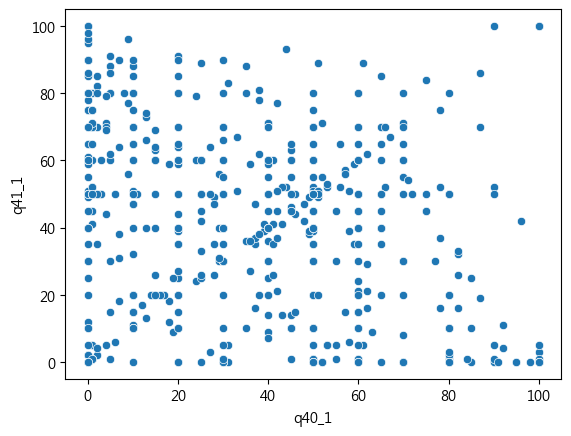

In [109]:
political_party = df.iloc[:, -9:-7]
for col in ['q40_1', 'q41_1']:
    political_party[col]= political_party[col].replace({'非常冰冷':0, '非常溫暖':100}).astype(float)
# political_party = political_party.rename(columns={'q40_1':'國民黨溫暖程度', 'q41_1':'民進黨溫暖程度'})
# political_party.info()
political_party['q40_1']= political_party['q40_1'].replace('非常冰冷', 0)
political_party['q40_1']= political_party['q40_1'].replace('非常溫暖', 100)
political_party['q41_1']= political_party['q41_1'].replace('非常冰冷', 0)
political_party['q41_1']= political_party['q41_1'].replace('非常溫暖', 100)
political_party['q40_1']= pd.to_numeric(political_party['q40_1'])
political_party['q41_1']= pd.to_numeric(political_party['q41_1'])
print(political_party.describe().T)
sns.scatterplot(data=political_party, x='q40_1', y='q41_1')

In [110]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(political_party['q40_1'], political_party['q41_1'])
different = political_party['q40_1']-political_party['q41_1']
mean_q40 = political_party['q40_1'].mean()
mean_q41 = political_party['q41_1'].mean()
mean_different = different.mean()
std_different = different.std(ddof=1)
cohen_d = mean_different/std_different if std_different != 0 else np.nan

print(f"N = {len(political_party)}")
print(f"Mean(Q40_1 國民黨溫度) = {mean_q40:.4f}")
print(f"Mean(Q41_1 民進黨溫度) = {mean_q41:.4f}")
print(f"Mean difference (Q41_1 - Q40_1) = {mean_different:.4f}")
print(f"t = {t_stat:.3f}, p = {p_value:.6f}, 小於0.05有顯著")
# print(f"Cohen's dz (paired) = {cohen_d:.4f}")

N = 685
Mean(Q40_1 國民黨溫度) = 37.0555
Mean(Q41_1 民進黨溫度) = 41.5577
Mean difference (Q41_1 - Q40_1) = -4.5022
t = -2.998, p = 0.002819, 小於0.05有顯著


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系統找不到指定的檔案。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1538

           N  mean_q40  mean_q41  mean_diff
cluster                                    
0        106     68.45      9.50     -58.95
1        281     51.38     52.03       0.65
2        154      9.92     68.12      58.20
3        144     15.02     16.31       1.29


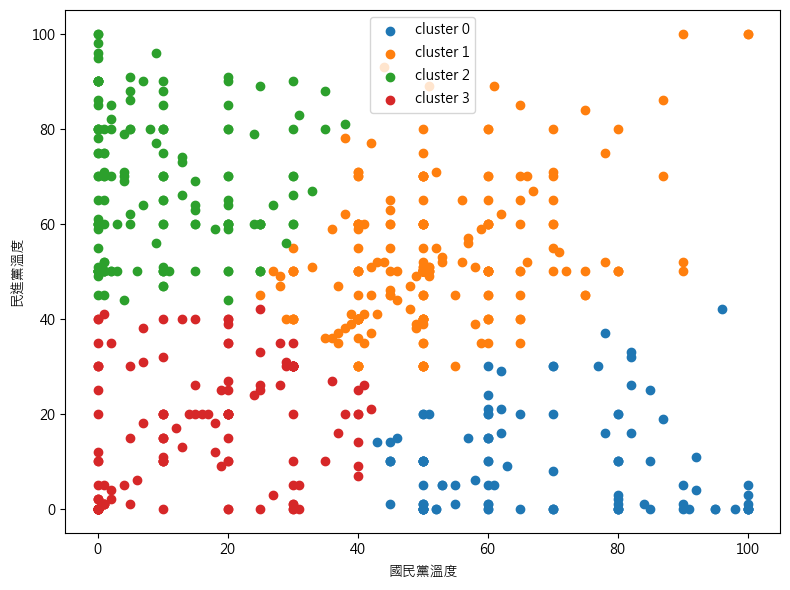

各群均值：
           q40_1    q41_1
cluster                  
0        68.4528   9.5000
1        51.3772  52.0320
2         9.9156  68.1169
3        15.0208  16.3125


In [111]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
X = political_party.to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
political_party = political_party.assign(cluster=labels)
cluster_summary = (political_party.groupby("cluster").agg(N=("cluster", "size"),
                                                          mean_q40=("q40_1", "mean"),
                                                          mean_q41=("q41_1", "mean"),)
                                                          .assign(mean_diff=lambda d: d["mean_q41"]-d["mean_q40"]).sort_values("cluster"))
print(cluster_summary.round(2))

plt.figure(figsize=(8, 6))
for c in range(4):
    idx = political_party["cluster"] == c
    plt.scatter(political_party.loc[idx, "q40_1"], political_party.loc[idx, "q41_1"], label=f"cluster {c}")
plt.xlabel("國民黨溫度")
plt.ylabel("民進黨溫度")
plt.legend()
plt.tight_layout()
plt.show()

# political_party['cluster'] = political_party['cluster'].replace({0:'親藍', 1:'雙重認同', 2:'親綠', 3:'雙重冷感'})

cluster_means = political_party.groupby("cluster")[['q40_1', 'q41_1']].mean()
print("各群均值：")
print(cluster_means.round(4))



---
---


## 分析

### 信效度分析
- 題目鑑別度
- 題目與整體的概念一致性
- 題目對整體信度的貢獻（拉高還是拉低整體內部一致性）

[Cronbach alpha](https://en.wikipedia.org/wiki/Cronbach%27s_alpha)

[Confidence interval for Cronbach's Alpha](https://search.r-project.org/CRAN/refmans/cocron/html/cronbach.alpha.CI.html)

#### KMO值, Bartelett's test
- 判斷是否適合做 探索性因素分析 (EFA)／主成分分析 (PCA)

- ≥ .90 → Marvelous (極佳)
- .80–.89 → Meritorious
- .70–.79 → Middling
- .60–.69 → Mediocre
- .50–.59 → Miserable
- < .50 → Unacceptable → 不建議做 EFA（探索性因子分析）

---
---

### EDA

In [122]:
internet_attack

,q22_01_1,q22_02_1,q22_03_1,q22_04_1,q22_05_1,q23_01_1,q23_02_1,q23_03_1,q23_04_1,q23_05_1,cluster
0,2,2,2,2,2,1,1,1,1,1,1
1,4,4,4,3,3,1,1,1,1,1,2
2,4,3,4,3,4,1,1,1,1,1,1
3,4,4,4,4,4,3,3,3,4,4,2
4,3,3,3,3,4,1,1,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...
680,3,3,3,2,4,1,1,1,1,1,3
681,4,4,4,3,3,3,3,3,1,3,3
682,4,4,4,3,3,1,1,1,1,1,2
683,4,3,3,2,3,2,1,1,1,1,2


In [124]:
political_party

,q40_1,q41_1,cluster
0,65.0,65.0,1
1,0.0,90.0,2
2,50.0,35.0,1
3,2.0,70.0,2
4,40.0,60.0,1
...,...,...,...
680,15.0,20.0,3
681,4.0,5.0,3
682,2.0,50.0,2
683,1.0,50.0,2


In [123]:
happiness

,q38_01_1,q38_02_1,q39_1,total
0,4,3,4,13
1,3,4,3,15
2,4,3,3,13
3,4,4,3,15
4,4,4,4,16
...,...,...,...,...
680,3,2,3,11
681,3,2,4,11
682,4,4,4,16
683,2,3,2,10


In [142]:
import numpy as np
import pandas as pd

cols = ['q33_1', 'q28_1', 'q28_2', 'q29_1', 'q29_2', 'q29_4']
dfc = cancel_culture.copy()

# 1) 轉數值（未對應、空白 → NaN）
for c in cols:
    dfc[c] = pd.to_numeric(dfc[c], errors='coerce')

# 2) 建立 0–1 指標
# 行為(0/1)：B = (q28_1, q28_2) 的「可用均值」
B = dfc[['q28_1','q28_2']].mean(axis=1, skipna=True)

# 觸發(0/1)：T = (q29_1, q29_2, q29_4) 的「可用均值」
T = dfc[['q29_1','q29_2','q29_4']].mean(axis=1, skipna=True)

# 重要性(1–5 → 0–1)：I = (q33_1-1)/4
I = (dfc['q33_1'] - 1) / 4

# 若某一構面完全缺資料，保留 NaN（避免硬補造成偏誤）
S_raw = 0.5*B + 0.3*I + 0.2*T

# 3) 轉 1–10 分
dfc['Score10'] = 1 + 9*S_raw

# 4) 依規則分類
label = np.where(dfc['Score10'] >= 6.0, '會抵制', '不會抵制')

# 覆寫條件：只要曾有行為(取消關注/拒看) → 會抵制
did_action = (dfc['q28_1'] == 1) | (dfc['q28_2'] == 1)
label = np.where(did_action, '會抵制', label)

dfc['resist_label'] = label

# 5) 簡要摘要
summary = {
    'n': len(dfc),
    'n_會抵制': int((dfc['resist_label']=='會抵制').sum()),
    'n_不會抵制': int((dfc['resist_label']=='不會抵制').sum()),
    '覆寫為會抵制_人數': int(((dfc['Score10'] < 6.0) & did_action).sum()),
}
print(summary)

# 如需只保留本題目相關欄位與結果：
out_cols = cols + ['resist_label']
cancel_culture = dfc[out_cols]
# display(result_df.head())  # 在 notebook 可顯示


{'n': 685, 'n_會抵制': 475, 'n_不會抵制': 210, '覆寫為會抵制_人數': 174}


In [144]:
cancel_culture

,q33_1,q28_1,q28_2,q29_1,q29_2,q29_4,resist_label
0,3,0,0,0,0,0,不會抵制
1,3,0,1,0,1,1,會抵制
2,3,0,0,0,0,0,不會抵制
3,3,1,1,1,1,1,會抵制
4,4,1,1,1,0,1,會抵制
...,...,...,...,...,...,...,...
680,4,1,1,0,0,1,會抵制
681,2,1,1,1,1,1,會抵制
682,3,0,1,1,0,1,會抵制
683,2,1,1,1,0,1,會抵制


In [151]:
full_df = pd.concat([internet_attack.drop(columns=['cluster']), happiness.drop(columns='total'), political_party['cluster'], individual[['q1', 'age_g', 'edu_g']], cancel_culture['resist_label']],axis=1)

In [154]:
full_df

,q22_01_1,q22_02_1,q22_03_1,q22_04_1,q22_05_1,q23_01_1,q23_02_1,q23_03_1,q23_04_1,q23_05_1,q38_01_1,q38_02_1,q39_1,cluster,q1,age_g,edu_g,resist_label
0,2,2,2,2,2,1,1,1,1,1,4,3,4,1,女,中年,研究所以上,不會抵制
1,4,4,4,3,3,1,1,1,1,1,3,4,3,2,男,中年,研究所以上,會抵制
2,4,3,4,3,4,1,1,1,1,1,4,3,3,1,女,壯年,研究所以上,不會抵制
3,4,4,4,4,4,3,3,3,4,4,4,4,3,2,男,青年,研究所以上,會抵制
4,3,3,3,3,4,1,1,1,1,2,4,4,4,1,女,青年,大學,會抵制
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,3,3,3,2,4,1,1,1,1,1,3,2,3,3,男,青年,大學,會抵制
681,4,4,4,3,3,3,3,3,1,3,3,2,4,3,女,青年,大學,會抵制
682,4,4,4,3,3,1,1,1,1,1,4,4,4,2,女,壯年,研究所以上,會抵制
683,4,3,3,2,3,2,1,1,1,1,2,3,2,2,女,青年,大學,會抵制


In [113]:
full_df = full_df.copy()
full_df['net_attack_mean'] = np.round((full_df.iloc[:, 0:10].sum(axis=1))/9, 2)
full_df['happiness_mean'] = np.round((full_df.iloc[:, 10:13].sum(axis=1))/3, 2)
full_df['cluster'] = full_df['cluster'].replace({0:'親藍', 1:'雙重認同', 2:'親綠', 3:'雙重冷漠'})
# 只保留 親藍 與 親綠
df_sub = full_df[full_df["cluster"].isin(["親藍", "親綠"])].reset_index(drop=True)
df_sub['cluster'].value_counts()

cluster
親綠    154
親藍    106
Name: count, dtype: int64

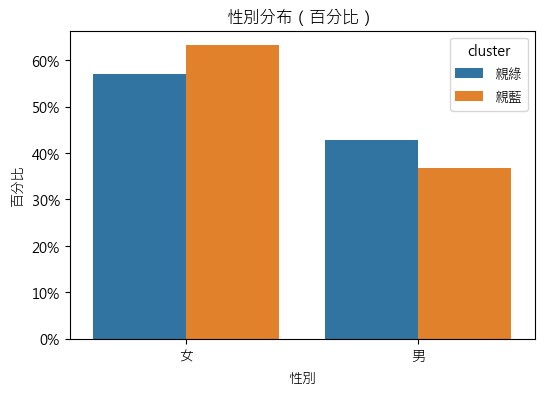

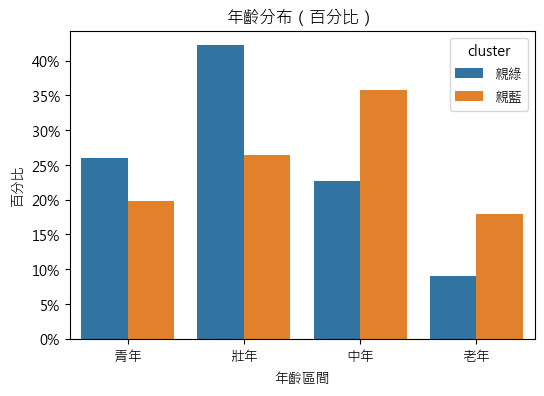

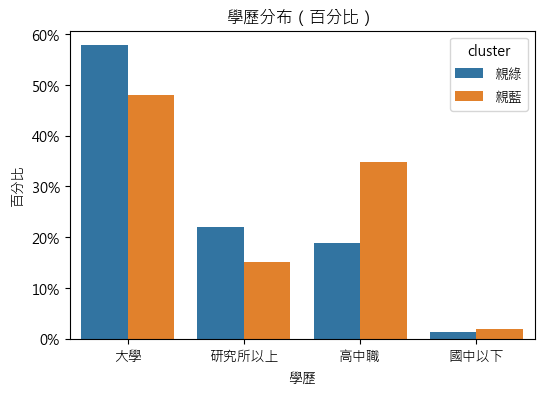

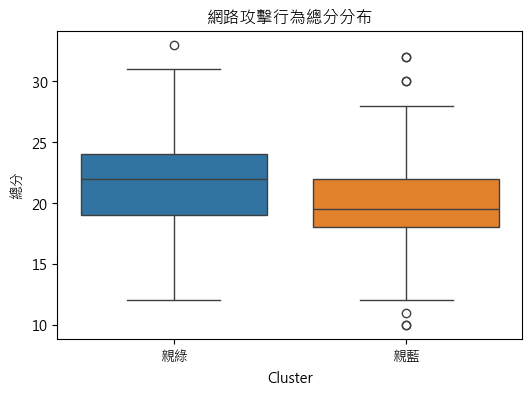

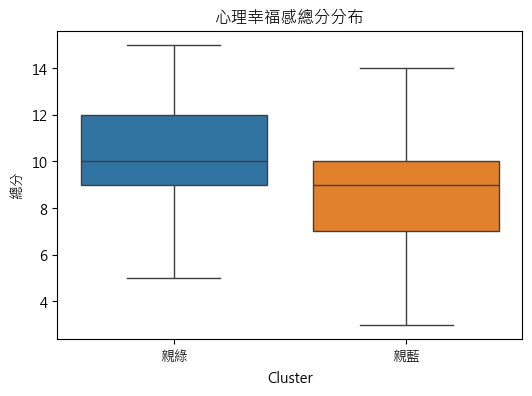

In [114]:
# 性別
gender_percent = df_sub.groupby("cluster")["q1"].value_counts(normalize=True).rename("percent").reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=gender_percent, x="q1", y="percent", hue="cluster")
plt.title("性別分布（百分比）")
plt.ylabel("百分比")
plt.xlabel("性別")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")
plt.show()

# 年齡
age_percent = df_sub.groupby("cluster")["age_g"].value_counts(normalize=True).rename("percent").reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=age_percent, x="age_g", y="percent", hue="cluster")
plt.title("年齡分布（百分比）")
plt.ylabel("百分比")
plt.xlabel("年齡區間")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")
plt.show()

# 學歷
edu_percent = df_sub.groupby("cluster")["edu_g"].value_counts(normalize=True).rename("percent").reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=edu_percent, x="edu_g", y="percent", hue="cluster")
plt.title("學歷分布（百分比）")
plt.ylabel("百分比")
plt.xlabel("學歷")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")
plt.show()

# 只保留親藍、親綠
df_sub = df_sub[df_sub["cluster"].isin(["親藍", "親綠"])]

# 攻擊行為總分
attack_vars = ["q22_01_1","q22_02_1","q22_03_1","q22_04_1","q22_05_1",
               "q23_01_1","q23_02_1","q23_03_1","q23_04_1"]
df_sub["net_attack_total"] = df_sub[attack_vars].sum(axis=1)
plt.figure(figsize=(6,4))
sns.boxplot(data=df_sub, x="cluster", y="net_attack_total", hue='cluster')
plt.title("網路攻擊行為總分分布")
plt.xlabel("Cluster")
plt.ylabel("總分")
plt.show()

# 幸福感總分
happy_vars = ["q38_01_1","q38_02_1","q39_1"]
df_sub["happiness_total"] = df_sub[happy_vars].sum(axis=1)
plt.figure(figsize=(6,4))
sns.boxplot(data=df_sub, x="cluster", y="happiness_total", hue='cluster')
plt.title("心理幸福感總分分布")
plt.xlabel("Cluster")
plt.ylabel("總分")
plt.show()

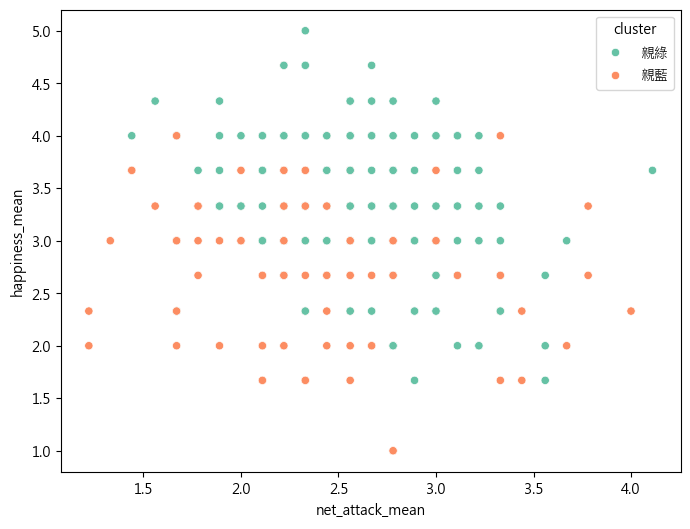

In [115]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sub, x='net_attack_mean', y='happiness_mean', hue='cluster', palette='Set2')
plt.show()

C:\Users\No\AppData\Local\Temp\ipykernel_8976\1027052819.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=count_df, x="Question", y="Count", hue="cluster", ci=None)


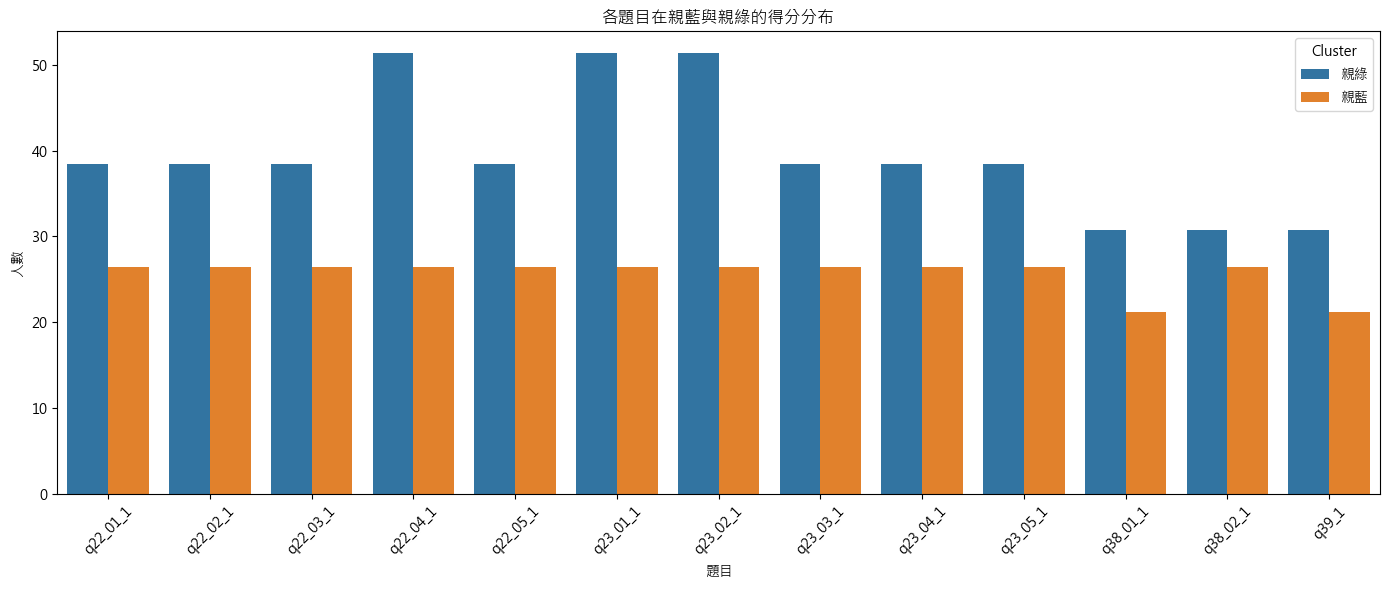

In [116]:
vars_interest = [
    "q22_01_1","q22_02_1","q22_03_1","q22_04_1","q22_05_1",
    "q23_01_1","q23_02_1","q23_03_1","q23_04_1","q23_05_1",
    "q38_01_1","q38_02_1","q39_1"
]

# 轉成長格式
df_long = df_sub.melt(id_vars="cluster", value_vars=vars_interest,
                      var_name="Question", value_name="Score")

# 計算每題每分數的計數
count_df = df_long.groupby(["Question", "Score", "cluster"]).size().reset_index(name="Count")

# 繪圖
plt.figure(figsize=(14, 6))
sns.barplot(data=count_df, x="Question", y="Count", hue="cluster", ci=None)
plt.xticks(rotation=45)
plt.title("各題目在親藍與親綠的得分分布")
plt.xlabel("題目")
plt.ylabel("人數")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### PCA

In [117]:
df_sub.head(1)

,q22_01_1,q22_02_1,q22_03_1,q22_04_1,q22_05_1,q23_01_1,q23_02_1,q23_03_1,q23_04_1,q23_05_1,...,q38_02_1,q39_1,cluster,q1,age_g,edu_g,net_attack_mean,happiness_mean,net_attack_total,happiness_total
0,4,4,4,3,3,1,1,1,1,1,...,4,3,親綠,男,中年,研究所以上,2.56,3.33,22,10


   Component  Eigenvalue  Prop.Var  Cum.Prop
0          1      2.6538    0.2940    0.2940
1          2      1.6484    0.1826    0.4766
2          3      0.9921    0.1099    0.5865
3          4      0.7303    0.0809    0.6674
4          5      0.5716    0.0633    0.7307


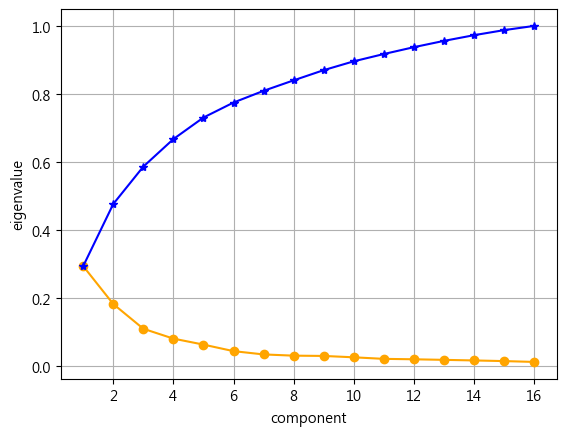

        PC1       PC2
0 -0.327036  0.844702
1 -3.790460  1.773479
2 -0.023560  0.921404
3  0.359499  2.119085
4 -0.301779  0.008764


In [118]:
from sklearn.decomposition import PCA
vars_ = [
    "q22_01_1","q22_02_1","q22_03_1","q22_04_1","q22_05_1",
    "q23_01_1","q23_02_1","q23_03_1","q23_04_1","q23_05_1",
    "q38_01_1","q38_02_1","q39_1", 'q1', 'age_g', 'edu_g']
df_num = df_sub.copy()
gender_map = {"男": 0, "女": 1}
df_num["q1"] = df_num["q1"].map(gender_map)
age_map = {"青年": 1, "壯年": 2, "中年": 3, "老年": 4}
df_num["age_g"] = df_num["age_g"].map(age_map)
edu_map = {"國中以下": 1, "高中職": 2, "大學": 3, "研究所以上": 4}
df_num["edu_g"] = df_num["edu_g"].map(edu_map)

X = df_num.drop(columns=['net_attack_mean', 'happiness_mean', 'cluster', 'net_attack_total', 'happiness_total']).values
pca = PCA().fit(X)
eigenvalues = pca.explained_variance_
eigenvalues_ratio = pca.explained_variance_ratio_
cum_eigenvalues = eigenvalues_ratio.cumsum()

eig_table = pd.DataFrame({'Component': np.arange(1, len(eigenvalues)+1),'Eigenvalue': np.round(eigenvalues, 4),'Prop.Var': np.round(eigenvalues_ratio, 4),'Cum.Prop': np.round(cum_eigenvalues, 4)})
print(eig_table.head(5))

plt.plot(range(1, len(eigenvalues_ratio)+1), eigenvalues_ratio, marker='o', color='orange')
plt.plot(range(1, len(cum_eigenvalues)+1), cum_eigenvalues, marker='*', color='b')
plt.xlabel('component')
plt.ylabel('eigenvalue')
plt.grid()
plt.show()

pca_k = PCA(n_components=2).fit(X)
loadings = pd.DataFrame(pca_k.components_.T, index=vars_, columns=[f'PC{i+1}' for i in range(2)])

scores = pca_k.transform(X)
df_num_scores = pd.DataFrame(scores, columns=[f'PC{i+1}' for i in range(2)], index=df_num.index)
print(df_num_scores.head())

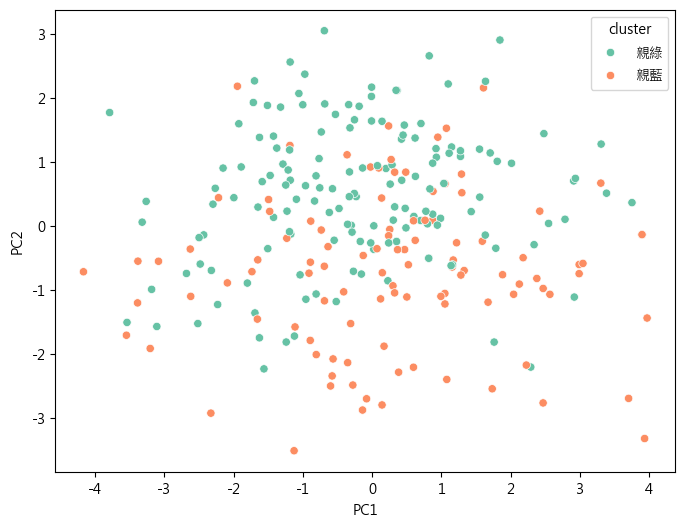

In [119]:
df_some = pd.concat([df_num_scores, df_num['cluster']], axis=1)
plt.figure(figsize=(8, 6))
sns.scatterplot(data = df_some, x='PC1', y='PC2', hue='cluster', palette='Set2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [120]:
from scipy import stats
internet_attack = pd.concat([internet_attack.drop(columns='total'), political_party['cluster']], axis=1)

In [121]:
likert_items = [f"q22_0{i}_1" for i in range(1,6)] + [f"q23_0{i}_1" for i in range(1,6)]
selected_features = []
for col in likert_items:
    if col not in internet_attack.columns:
        continue
    groups = [internet_attack.loc[internet_attack['cluster']==g, col] for g in range(4)]
    if all(len(g)>0 for g in groups):
        H, p = stats.kruskal(*groups)
        if p < 0.05:
            selected_features.append(col)
print('selected features:', selected_features)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X = internet_attack[selected_features]
y = internet_attack['cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))


selected features: ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1', 'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_05_1']
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.45      0.85      0.59        85
           2       0.31      0.09      0.14        46
           3       0.26      0.21      0.23        43

    accuracy                           0.41       206
   macro avg       0.26      0.29      0.24       206
weighted avg       0.31      0.41      0.32       206



c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\No\anacon